# Monte Carlo methods

Following **Chapter 5** from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [44]:
import math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML
%matplotlib notebook

### Blackjack

In [2]:
def draw_card():
    # Cards are 1 (Ace) through 10, with J/Q/K counted as 10
    return np.random.randint(1, 11)


def add_card(total: int, usable_ace: bool, card: int):
    """
    Update hand total and usable ace status after drawing a card.
    """
    if card == 1:  # Ace
        if total + 11 <= 21:
            total += 11
            usable_ace = True
        else:
            total += 1
    else:
        total += card

    # Convert usable ace from 11 -> 1 if bust
    if total > 21 and usable_ace:
        total -= 10
        usable_ace = False

    return total, usable_ace


def run_episode(pi_s: Callable, epsilon: Optional[float] = None) -> tuple[list, list, int]:
    if not epsilon:
        epsilon = 0
    
    states, actions = [], []

    # ----- Dealer initial hand -----
    dealer_showing = draw_card()
    dealer_hidden = draw_card()

    dealer_sum = 0
    dealer_usable_ace = False
    dealer_sum, dealer_usable_ace = add_card(
        dealer_sum, dealer_usable_ace, dealer_showing
    )
    dealer_sum, dealer_usable_ace = add_card(
        dealer_sum, dealer_usable_ace, dealer_hidden
    )

    # ----- Player initial hand -----
    player_sum = 0
    usable_ace = False
    player_sum, usable_ace = add_card(
        player_sum, usable_ace, draw_card()
    )
    player_sum, usable_ace = add_card(
        player_sum, usable_ace, draw_card()
    )

    s = (player_sum, dealer_showing, usable_ace)

    # Natural blackjack
    if player_sum == 21:
        if dealer_sum == 21:
            return [s], [0], 0
        return [s], [0], 1

    # ----- Player turn -----
    while True:
        s = (player_sum, dealer_showing, usable_ace)
        if np.random.rand() < epsilon:
            a = np.random.randint(2) # 1 = hit, 0 = stick
        else:
            a = pi_s(s) # 1 = hit, 0 = stick
        states.append(s)
        actions.append(a)

        if a == 1:  # hit
            card = draw_card()
            player_sum, usable_ace = add_card(
                player_sum, usable_ace, card
            )

            if player_sum > 21:
                return states, actions, -1 # player bust

        else:  # stick
            break

    # ----- Dealer turn -----
    while dealer_sum < 17: # Dealer fixed policy
        card = draw_card()
        dealer_sum, dealer_usable_ace = add_card(
            dealer_sum, dealer_usable_ace, card
        )

    # ----- Determine outcome -----
    if dealer_sum > 21:
        _return = 1 # dealer bust, player win
    elif player_sum > dealer_sum:
        _return = 1 # player win
    elif player_sum < dealer_sum:
        _return = -1 # dealer win
    else:
        _return = 0 # draw

    return states, actions, _return

def initialize_V_pi():
    V_pi = {}
    for usable_ace in [True, False]:
        for dealer_showing in list(range(1, 11)): # Dealer can show between 1-10
            for player_sum in list(range(12, 22)): # Player automatically hits under 12
                s = (player_sum, dealer_showing, usable_ace)
                V_pi[s] = 0
    return V_pi

def initialize_returns():
    returns = {}
    for usable_ace in [True, False]:
        for dealer_showing in list(range(1, 11)): # Dealer can show between 1-10
            for player_sum in list(range(12, 22)): # Player automatically hits under 12
                s = (player_sum, dealer_showing, usable_ace)
                returns[s] = []
    return returns

def plot_value_function(V_pi):
    """
    V_pi: dict mapping
        (player_sum, dealer_showing, usable_ace) -> value
    """

    dealer_showing = np.arange(1, 11)
    player_sum = np.arange(12, 22)

    X, Y = np.meshgrid(dealer_showing, player_sum)

    fig = plt.figure(figsize=(14, 6))

    for i, usable_ace in enumerate([True, False]):

        Z = np.zeros_like(X, dtype=float)

        for row, p_sum in enumerate(player_sum):
            for col, d_show in enumerate(dealer_showing):
                Z[row, col] = V_pi.get(
                    (p_sum, d_show, usable_ace),
                    0.0
                )

        ax = fig.add_subplot(1, 2, i + 1, projection="3d")

        ax.plot_surface(
            X,
            Y,
            Z,
            rstride=1,
            cstride=1,
            cmap="viridis",
            edgecolor="none"
        )

        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ax.set_zlabel("Value")

        ax.set_xticks(np.arange(1, 11))
        ax.set_yticks(np.arange(12, 22))

        ax.set_title(
            "Usable Ace" if usable_ace else "No Usable Ace"
        )

        ax.view_init(elev=25, azim=-135)

    plt.tight_layout()
    plt.show()

In [3]:
naive_deterministic_policy = lambda s:  0 if s[0] >= 20 else 1 # stick if 20 or 21, else hit

### Blackjack MC policy evaluation (prediction) - using state-value function

Page *92*. Reward calculation is skipped, as return is given directly per episode. No first-visit check required, as no states can be revisited in blackjack.

In [42]:
num_episodes = 100000

V_pi = initialize_V_pi()
returns = initialize_returns()

for i in tqdm(range(num_episodes), desc="Episode"):
    states, actions, _return = run_episode(pi_s=naive_deterministic_policy)
    for t in reversed(range(len(states))):
        s_t = states[t]
        if s_t not in V_pi.keys():
            continue
        returns[s_t].append(_return)
        V_pi[s_t] = np.mean(returns[s_t])

Episode: 100%|██████████| 100000/100000 [00:11<00:00, 8900.60it/s]


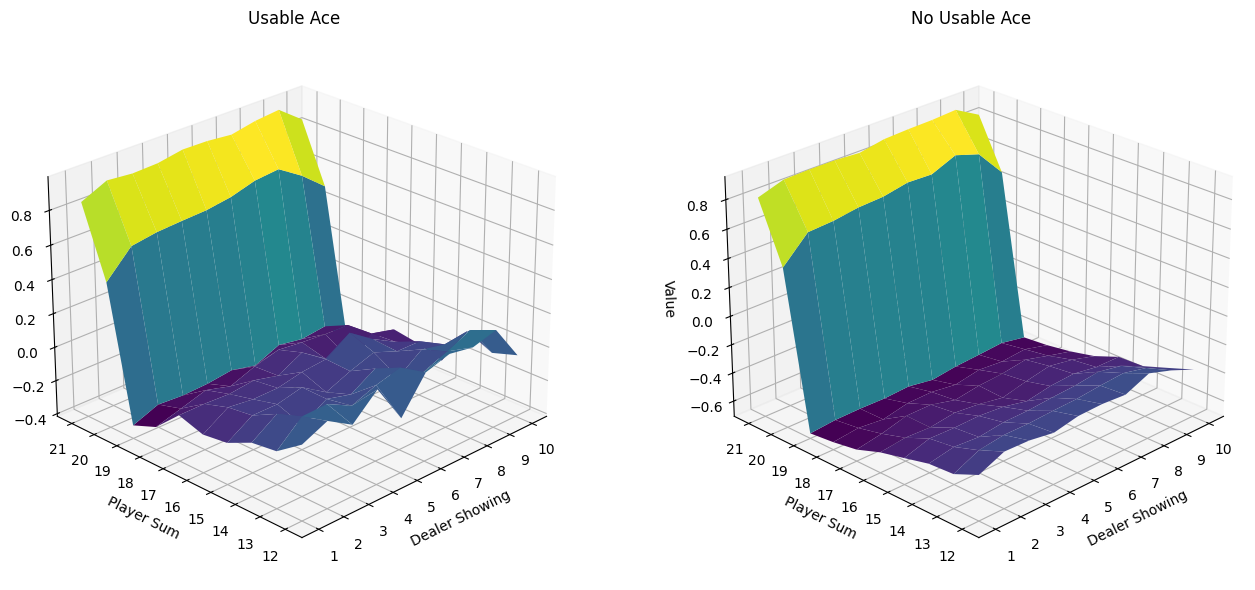

In [43]:
plot_value_function(V_pi)

### Blackjack MC policy evaluation (prediction) - using action-value function

Page *96*

In [11]:
def initialize_Q_pi(q_lower_bound: int = 12):
    Q_pi = {}
    for usable_ace in [True, False]:
        for dealer_showing in list(range(1, 11)): # Dealer can show between 1-10
            for player_sum in list(range(q_lower_bound, 22)):
                s = (player_sum, dealer_showing, usable_ace)
                Q_pi[s] = np.zeros(2) # Shape 2 - one for each action: stick (0), hit (1)
    return Q_pi

def initialize_q_counts(q_lower_bound: int = 12):
    counts = {}
    for usable_ace in [True, False]:
        for dealer_showing in list(range(1, 11)): # Dealer can show between 1-10
            for player_sum in list(range(q_lower_bound, 22)):
                s = (player_sum, dealer_showing, usable_ace)
                counts[s] = [0, 0]  # visit counts for stick (0) and hit (1)
    return counts

def plot_Q_function(Q_pi: dict):
    dealer_showing = np.arange(1, 11)
    player_sum = np.arange(12, 22)

    X, Y = np.meshgrid(dealer_showing, player_sum)

    fig = plt.figure(figsize=(16, 12))

    plot_num = 1

    for usable_ace in [True, False]:
        for action in [0, 1]:

            Z = np.zeros_like(X, dtype=float)

            for i, p_sum in enumerate(player_sum):
                for j, d_show in enumerate(dealer_showing):
                    Z[i, j] = Q_pi[(p_sum, d_show, usable_ace)][action]

            ax = fig.add_subplot(
                2, 2, plot_num,
                projection="3d"
            )

            ax.plot_surface(
                X,
                Y,
                Z,
                cmap="viridis",
                edgecolor="none"
            )

            ax.set_xlabel("Dealer Showing")
            ax.set_ylabel("Player Sum")
            ax.set_zlabel("Q(s,a)")

            title_action = "Stick" if action == 0 else "Hit"
            title_ace = "Usable Ace" if usable_ace else "No Usable Ace"

            ax.set_title(
                f"{title_ace} | {title_action}"
            )

            plot_num += 1

    plt.tight_layout()
    plt.show()

In [12]:
num_episodes = 500000

Q_pi = initialize_Q_pi()
counts = initialize_q_counts()

for i in tqdm(range(num_episodes), desc="Episode"):
    states, actions, _return = run_episode(pi_s=naive_deterministic_policy)
    for t in reversed(range(len(states))):
        s_t = states[t]
        a_t = actions[t]
        if s_t not in Q_pi.keys():
            continue
        counts[s_t][a_t] += 1
        Q_pi[s_t][a_t] += (_return - Q_pi[s_t][a_t]) / counts[s_t][a_t] # rolling average / standard online mean update

Episode: 100%|██████████| 500000/500000 [00:11<00:00, 42015.89it/s]


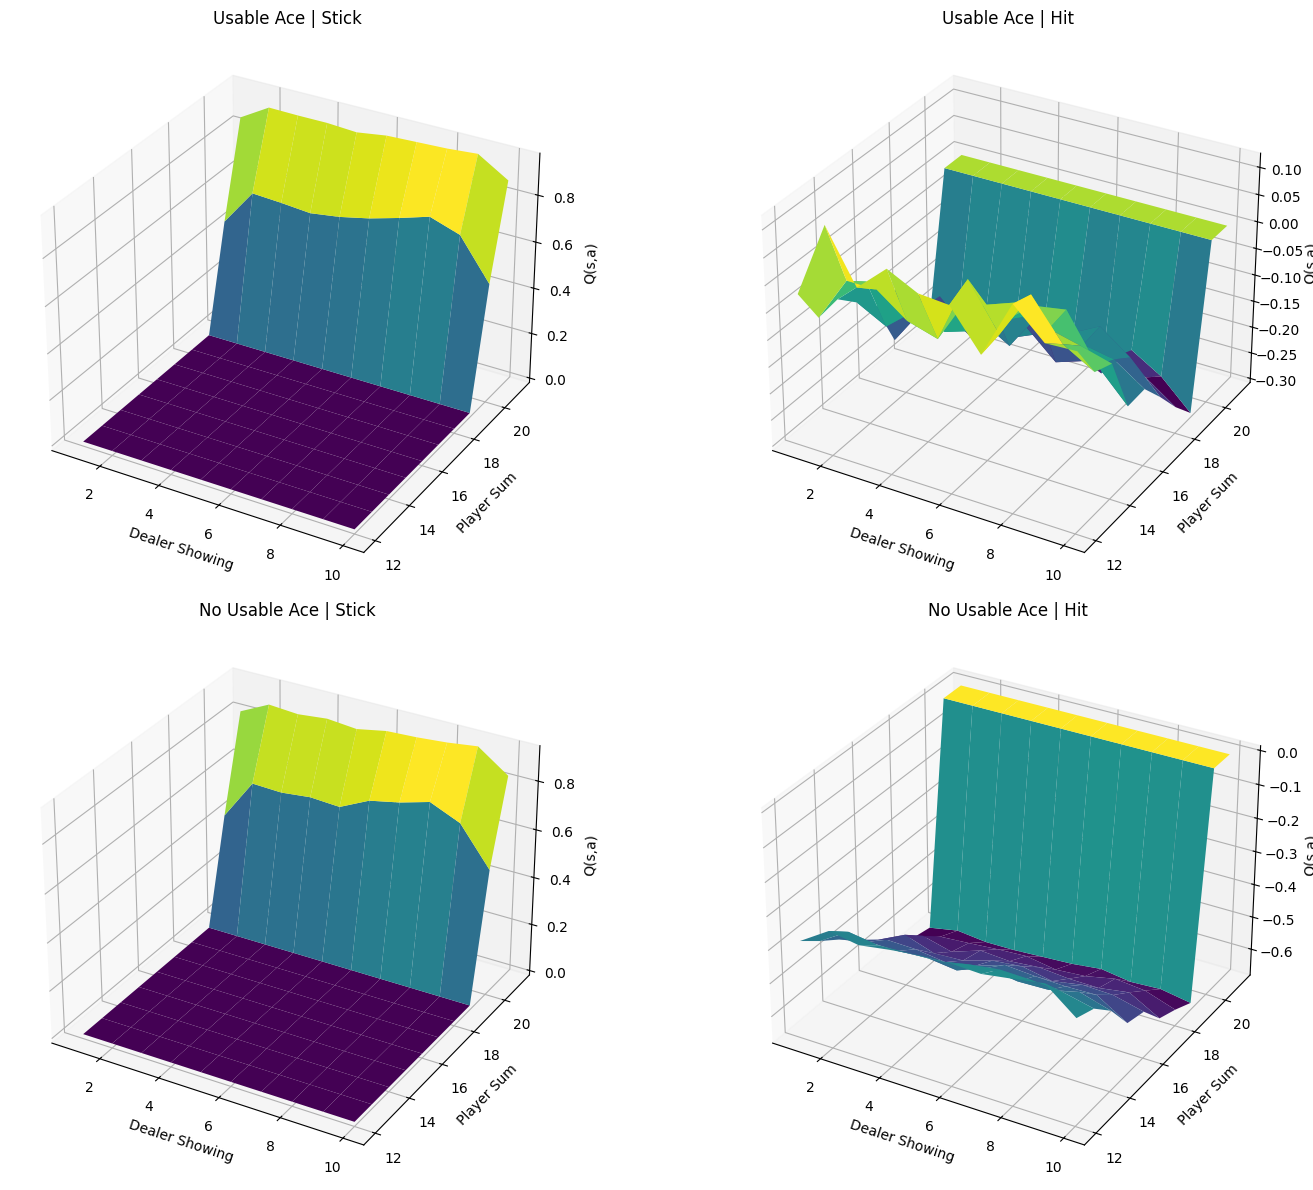

In [13]:
plot_Q_function(Q_pi)

### Blackjack MC control (without exploring starts)

Page *97* (MC Control) and *100* (without exploring starts)

In [15]:
def initialize_policy(S: Any):
    return {s: np.random.choice([0, 1]) for s in S}

def plot_blackjack_policy(policy):
    cmap = ListedColormap(["lightblue", "salmon"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, usable_ace in zip(axes, [True, False]):
        data = np.zeros((10, 10))

        for player_sum in range(12, 22):
            for dealer_showing in range(1, 11):
                data[player_sum - 12, dealer_showing - 1] = \
                    policy[(player_sum, dealer_showing, usable_ace)]

        ax.imshow(
            data,
            origin="lower",
            cmap=cmap,
            extent=[0.5, 10.5, 11.5, 21.5],
            aspect="auto"
        )

        ax.set_xticks(range(1, 11))
        ax.set_yticks(range(12, 22))
        ax.set_title(
            "Usable Ace" if usable_ace else "No Usable Ace"
        )
        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")

    plt.tight_layout()
    plt.show()

In [31]:
num_episodes = 1_000_000

Q_pi = initialize_Q_pi(q_lower_bound=1)
pi = initialize_policy(Q_pi.keys())
policy_fn = lambda s: pi[s]
counts = initialize_q_counts(q_lower_bound=1)

for i in tqdm(range(num_episodes), desc="Episode"):
    epsilon = max(0.01, 1 / np.sqrt(i + 1)) # exploration threshold - decaying schedule
    # Epsilon is used for exploration - here, epsilon-soft
    states, actions, _return = run_episode(pi_s=policy_fn, epsilon=epsilon)
    for t in reversed(range(len(states))):
        s_t = states[t]
        a_t = actions[t]
        if s_t not in Q_pi.keys():
            continue
        counts[s_t][a_t] += 1
        Q_pi[s_t][a_t] += (_return - Q_pi[s_t][a_t]) / counts[s_t][a_t] # rolling average / standard online mean update
        pi[s_t] = np.argmax(Q_pi[s_t])

Episode: 100%|██████████| 1000000/1000000 [00:30<00:00, 32701.76it/s]


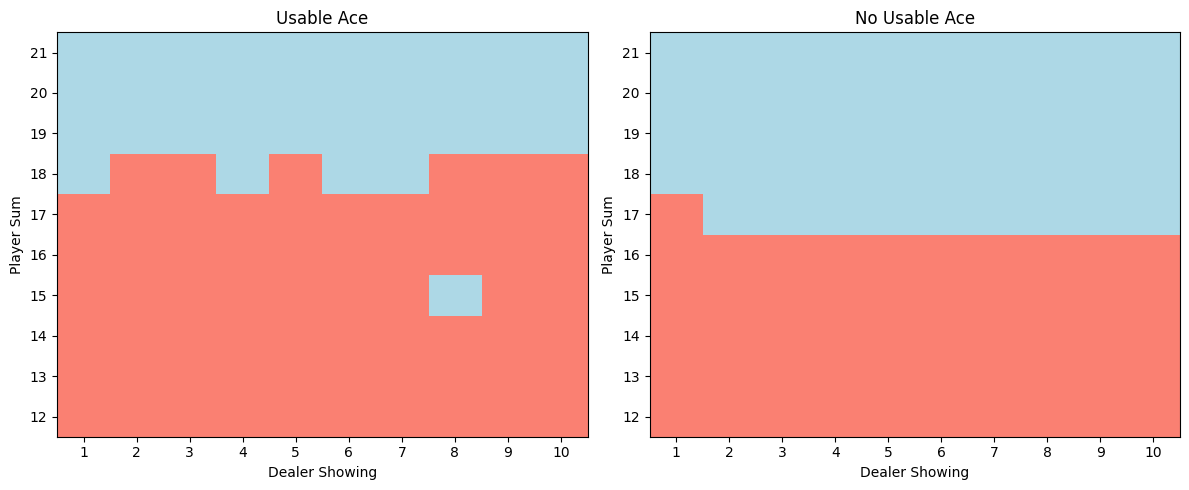

In [32]:
plot_blackjack_policy(pi)

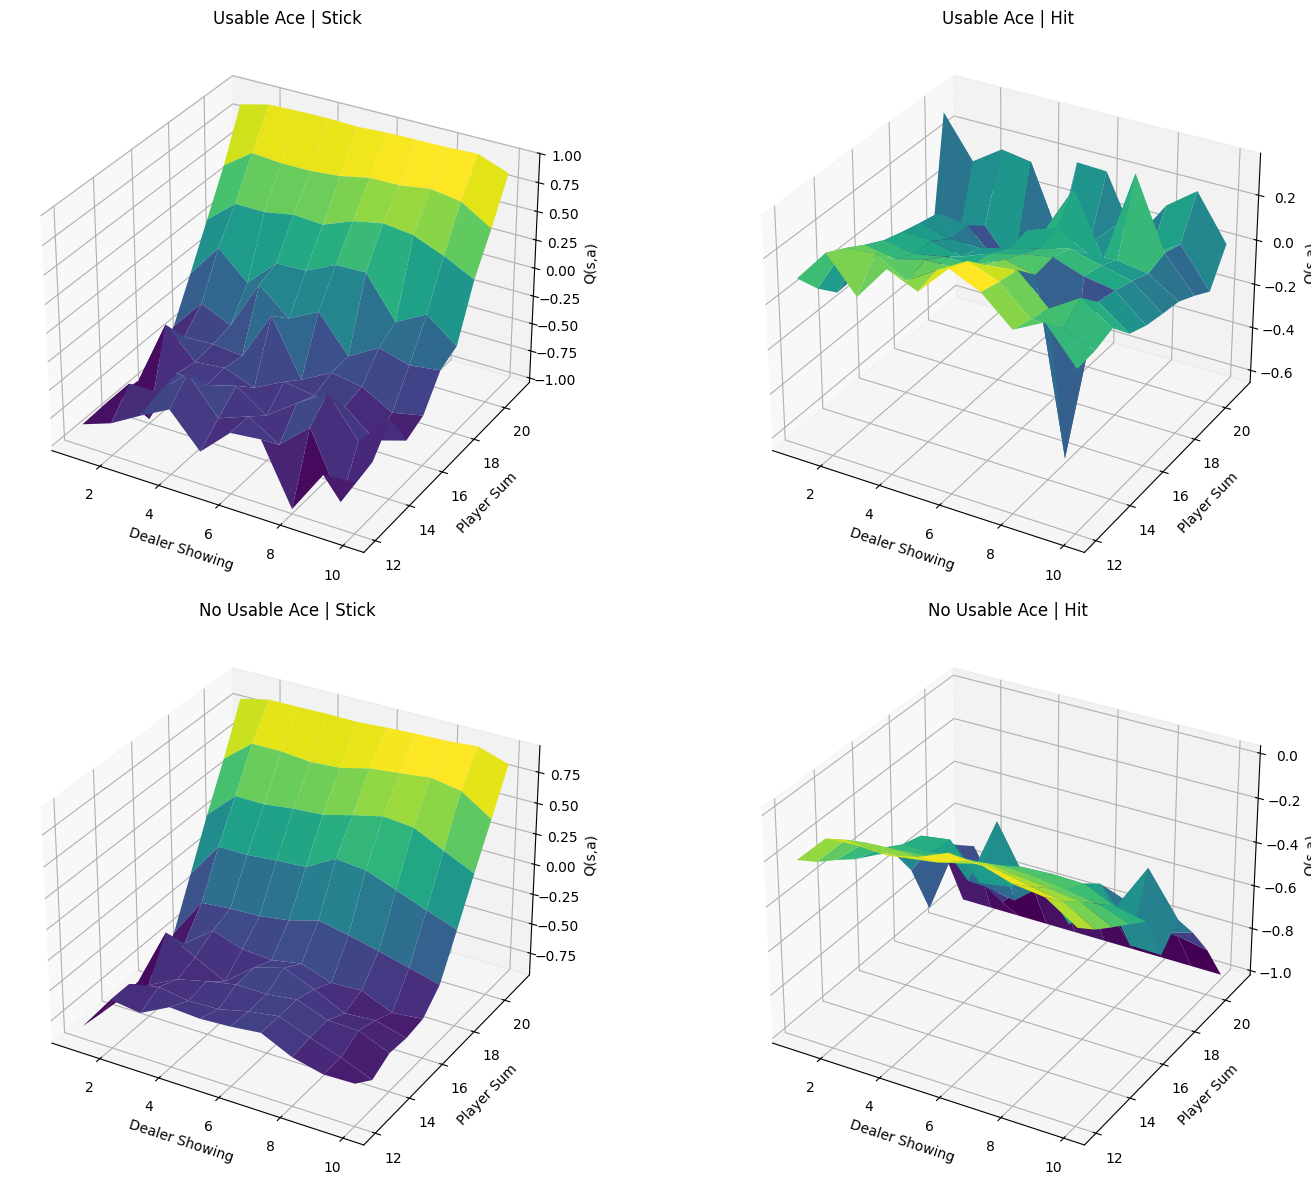

In [33]:
plot_Q_function(Q_pi)

### Off-policy prediction & control via importance sampling

Page *103* importance sampling, page *109* incremental implementation, page *110* control

In [34]:
def behavior_prob(s, a, epsilon, Q_pi):
    greedy = np.argmax(Q_pi[s])

    if a == greedy:
        return 1 - epsilon + epsilon / 2
    else:
        return epsilon / 2
    
def target_prob(s, a, pi): # deterministic greedy
    return 1.0 if a == pi[s] else 0.0

In [35]:
num_episodes = 2_000_000

Q_pi = initialize_Q_pi(q_lower_bound=1)
b_pi = pi.copy() # behaviour policy
t_pi = initialize_policy(Q_pi.keys()) # target policy
C = initialize_Q_pi(q_lower_bound=0)

for i in tqdm(range(num_episodes), desc="Episode"):
    epsilon = max(0.01, 1 / np.sqrt(i + 1)) # exploration threshold - decaying schedule
    # Epsilon is used for exploration - here, epsilon-soft
    states, actions, _return = run_episode(
        pi_s=lambda s: b_pi[s], # behavior policy used to generate the episode
        epsilon=epsilon
        )
    
    W = 1.0
    G = _return

    for t in reversed(range(len(states))):

        s_t = states[t]
        a_t = actions[t]

        if s_t not in Q_pi:
            continue

        C[s_t][a_t] += W # accumulate - sum of weights for this s, a

        Q_pi[s_t][a_t] += (
            W / C[s_t][a_t]
        ) * (
            G - Q_pi[s_t][a_t]
        ) # accumulate - incremental implementation of weighted average

        t_pi[s_t] = np.argmax(Q_pi[s_t]) # target policy - greedy wrt Q_pi

        # stop if action differs from current target policy
        if a_t != pi[s_t]:
            break

        W *= 1.0 / behavior_prob(
            s_t,
            a_t,
            epsilon,
            Q_pi
        )

Episode: 100%|██████████| 2000000/2000000 [01:13<00:00, 27052.77it/s]


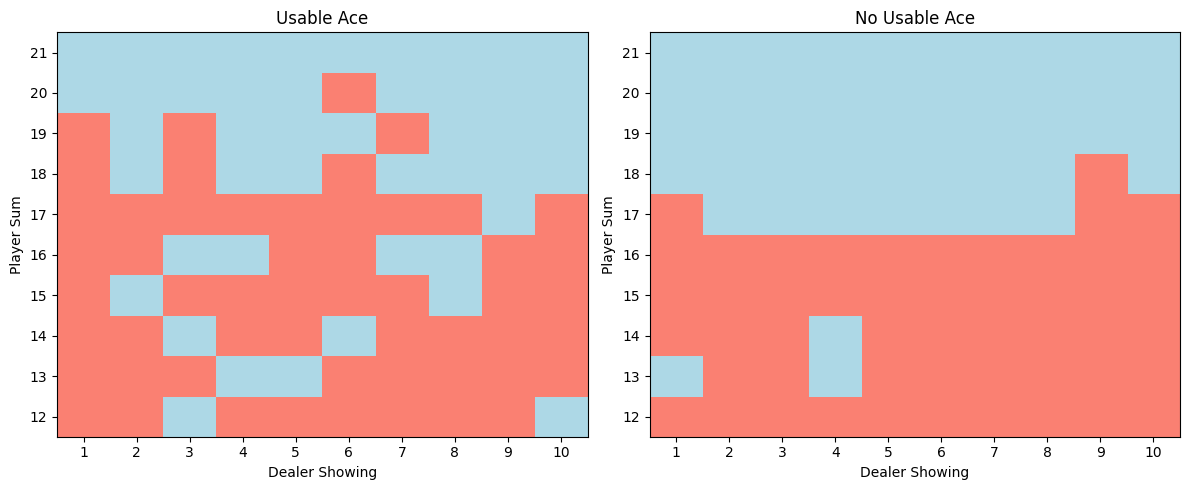

In [36]:
plot_blackjack_policy(t_pi)

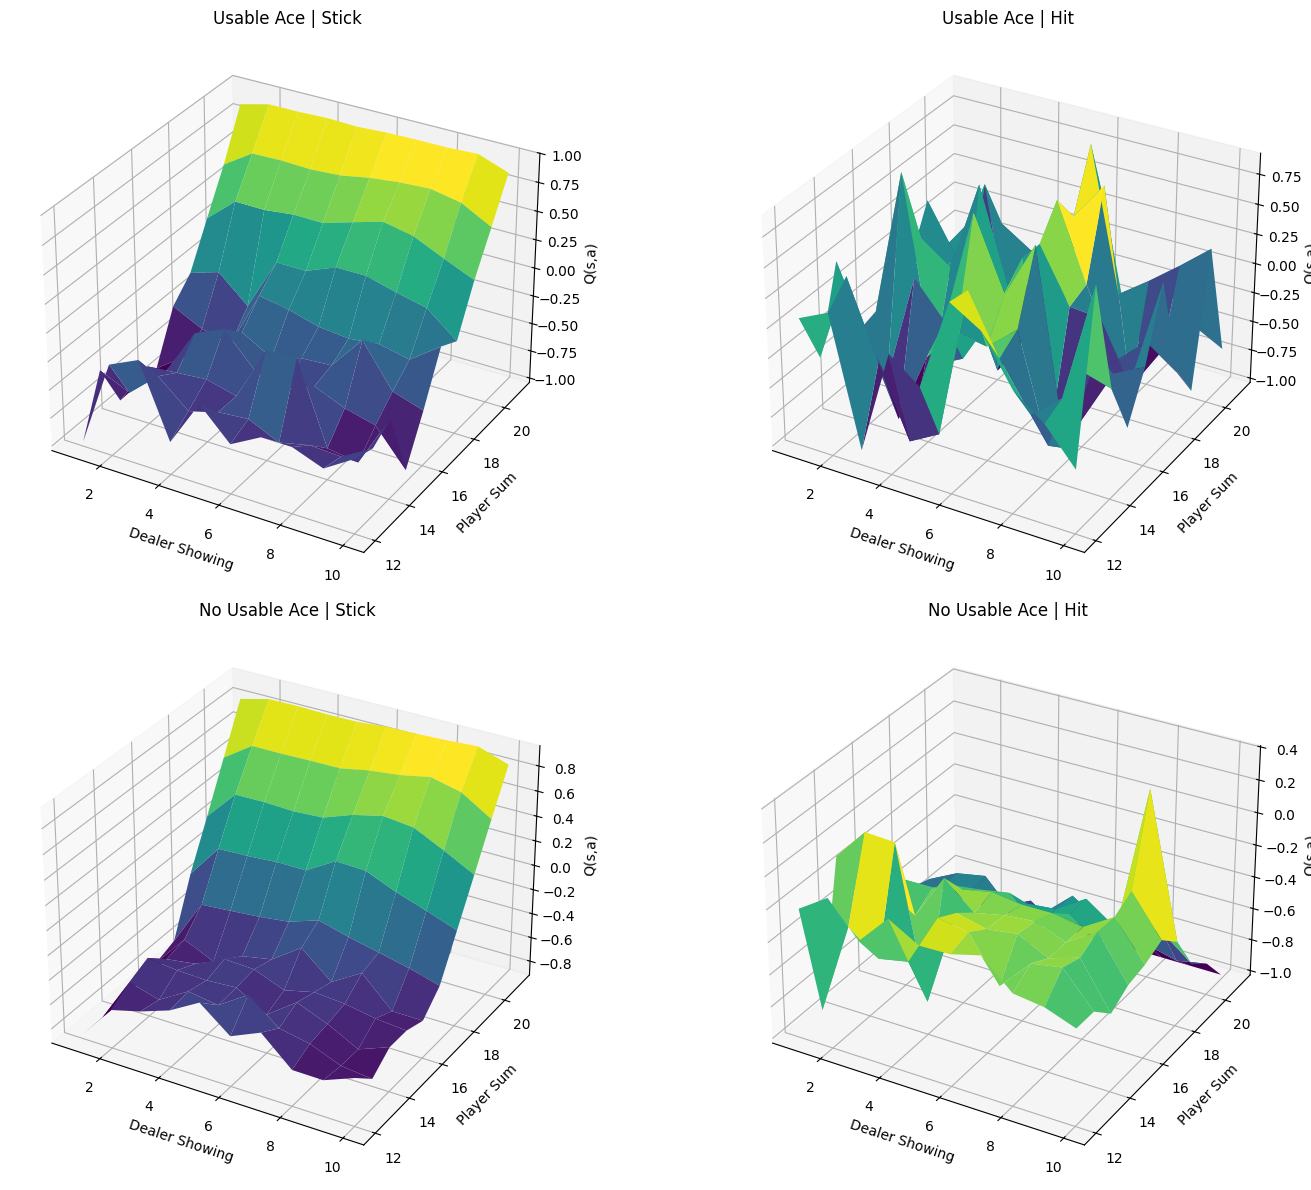

In [37]:
plot_Q_function(Q_pi)

### Off-policy Monte Carlo Control - Racecar Task

Chapter 5.7, page *110*

In [2]:
track_1 = np.array([
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,3],
[0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3],
[0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3],
[0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3],
[0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,3],
[0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
[0,0,0,0,2,2,2,2,2,2,0,0,0,0,0,0,0,0],
], dtype=np.int8)

In [ ]:
class RaceTrackEnv:

    _s: np.ndarray
    """State composed of 4 componenets, in order: grid_row, grid_col, h_vel, v_vel"""

    def __init__(self, grid: np.ndarray):
        self.grid = grid
        self.num_rows, self.num_cols = grid.shape

        self.starting_positions = np.argwhere(grid == 2)
        self.ending_positions = np.argwhere(grid == 3)

        self.episode = 0
        self.s = self._pick_starting_state()

    def reset(self) -> tuple[int, int, int, int]:
        self.episode += 1
        self.s = self._pick_starting_state()
        return tuple(self.s.tolist())

    def _pick_starting_state(self) -> np.ndarray:
        """
        State representation:

            [row, col, h_vel, v_vel]
        """
        pos = self.starting_positions[
            np.random.choice(len(self.starting_positions))
        ]

        vel = np.array([0, 0], dtype=np.int32)

        return np.concatenate([pos, vel])
    
    def _update_velocity(
        self,
        horizontal_update: int,
        vertical_update: int,
        fail_p: float = 0.1,
    ) -> tuple[int, int]:

        if np.random.random() <= fail_p:
            horizontal_update = 0
            vertical_update = 0

        h_vel = int(
            np.clip(self.s[2] + horizontal_update, 0, 5)
        )
        v_vel = int(
            np.clip(self.s[3] + vertical_update, 0, 5)
        )

        return h_vel, v_vel

    def _update_pos(
        self,
        h_vel: int,
        v_vel: int,
    ) -> tuple[int, int]:
        """
        Returns (row, col).
        """

        row = int(
            np.clip(self.s[0] - v_vel, 0, self.num_rows - 1)
        )

        col = int(
            np.clip(self.s[1] + h_vel, 0, self.num_cols - 1)
        )

        return row, col
    
    def _check_crash(
        self,
        old_row: int,
        old_col: int,
        new_row: int,
        new_col: int,
    ) -> bool:
        """
        Bresenham line traversal.
        Returns True iff any visited cell is a wall.
        """

        dr = abs(new_row - old_row)
        dc = abs(new_col - old_col)

        step_r = 1 if old_row < new_row else -1
        step_c = 1 if old_col < new_col else -1

        row, col = old_row, old_col

        if dc > dr:

            err = dc // 2

            while col != new_col:

                if self.grid[row, col] == 0:
                    return True

                err -= dr

                if err < 0:
                    row += step_r
                    err += dc

                col += step_c

        else:

            err = dr // 2

            while row != new_row:

                if self.grid[row, col] == 0:
                    return True

                err -= dc

                if err < 0:
                    col += step_c
                    err += dr

                row += step_r

        return self.grid[new_row, new_col] == 0

    def step(
        self,
        a: np.ndarray,
    ) -> tuple[float, tuple[int, int, int, int], bool]:

        reward = -1.0

        old_row = int(self.s[0])
        old_col = int(self.s[1])

        h_vel, v_vel = self._update_velocity(
            a[0],
            a[1],
        )

        new_row, new_col = self._update_pos(
            h_vel,
            v_vel,
        )

        crashed = self._check_crash(
            old_row,
            old_col,
            new_row,
            new_col,
        )

        if crashed:
            self.s = self._pick_starting_state()
            return reward, tuple(self.s.tolist()), False

        self.s = np.array(
            [new_row, new_col, h_vel, v_vel],
            dtype=np.int32,
        )

        finished = self.grid[new_row, new_col] == 3

        return reward, tuple(self.s.tolist()), finished


In [13]:
def initialize_Q_pi_racecar(
    env: RaceTrackEnv,
    num_actions: int,
):
    Q = {}

    for row in range(env.num_rows):
        for col in range(env.num_cols):
            for h_vel in range(6):
                for v_vel in range(6):

                    s = (
                        row,
                        col,
                        h_vel,
                        v_vel,
                    )

                    Q[s] = np.random.random(num_actions)

    return Q


def initialize_Q_counts_racecar(
    state_keys,
    num_actions: int,
):
    return {
        s: np.zeros(num_actions, dtype=np.int64)
        for s in state_keys
    }

In [48]:
ACTION_TO_ARROW = {
    (-1, -1): "↙",
    (-1,  0): "←",
    (-1,  1): "↖",
    ( 0, -1): "↓",
    ( 0,  0): "•",
    ( 0,  1): "↑",
    ( 1, -1): "↘",
    ( 1,  0): "→",
    ( 1,  1): "↗",
}

def plot_value_heatmap(
    env,
    Q,
    v_h=0,
    v_v=0,
):
    """
    Plot V(s)=max_a Q(s,a)
    for a fixed velocity slice.
    """

    V = np.full(
        (env.num_rows, env.num_cols),
        np.nan,
    )

    for row in range(env.num_rows):
        for col in range(env.num_cols):

            if env.grid[row, col] == 0:
                continue

            s = (row, col, v_h, v_v)

            if s in Q:
                V[row, col] = np.max(Q[s])

    plt.figure(figsize=(8, 12))

    plt.imshow(V, origin="upper")

    plt.colorbar(
        label="max_a Q(s,a)"
    )

    plt.title(
        f"Value Function Slice "
        f"(vh={v_h}, vv={v_v})"
    )

    plt.tight_layout()
    plt.show()

def plot_policy(
    env,
    Q,
    action_set,
    v_h=0,
    v_v=0,
):
    """
    Plot greedy policy for
    a fixed velocity slice.
    """

    fig, ax = plt.subplots(
        figsize=(8, 12)
    )

    ax.imshow(
        env.grid,
        origin="upper",
        alpha=0.3,
    )

    for row in range(env.num_rows):
        for col in range(env.num_cols):

            if env.grid[row, col] == 0:
                continue

            s = (
                row,
                col,
                v_h,
                v_v,
            )

            if s not in Q:
                continue

            a_idx = np.argmax(Q[s])

            action = action_set[a_idx]

            arrow = ACTION_TO_ARROW[action]

            ax.text(
                col,
                row,
                arrow,
                ha="center",
                va="center",
                fontsize=10,
            )

    ax.set_title(
        f"Greedy Policy "
        f"(vh={v_h}, vv={v_v})"
    )

    plt.tight_layout()
    plt.show()

def plot_greedy_rollouts(
    env,
    Q,
    action_set,
    num_rollouts=50,
    max_steps=500,
):
    """
    Draw trajectories generated
    by the greedy policy.
    """

    fig, ax = plt.subplots(
        figsize=(8, 12)
    )

    ax.imshow(
        env.grid,
        origin="upper",
    )

    for _ in range(num_rollouts):

        s = env.reset()

        rows = [s[0]]
        cols = [s[1]]

        for _ in range(max_steps):

            action_idx = np.argmax(
                Q[s]
            )

            a = np.array(
                action_set[action_idx]
            )

            _, s, done = env.step(a)

            rows.append(s[0])
            cols.append(s[1])

            if done:
                break

        ax.plot(
            cols,
            rows,
            linewidth=1,
            alpha=0.5,
        )

    ax.set_title(
        f"{num_rollouts} Greedy Rollouts"
    )

    plt.tight_layout()
    plt.show()

def animate_episode_with_trail(
    env,
    Q,
    action_set,
    max_steps=500,
    interval=100,
):

    states = []

    s = env.reset()
    states.append(s)

    for _ in range(max_steps):

        action_idx = np.argmax(Q[s])

        a = np.array(action_set[action_idx])

        _, s, done = env.step(a)

        states.append(s)

        if done:
            break

    fig, ax = plt.subplots(figsize=(8, 12))

    ax.imshow(
        env.grid,
        origin="upper",
        interpolation="nearest",
    )

    trail, = ax.plot(
        [],
        [],
        linewidth=2,
    )

    car = ax.scatter(
        [],
        [],
        s=150,
    )

    def update(frame):

        rows = [s[0] for s in states[:frame + 1]]
        cols = [s[1] for s in states[:frame + 1]]

        trail.set_data(cols, rows)

        car.set_offsets(
            [[cols[-1], rows[-1]]]
        )

        return trail, car

    anim = FuncAnimation(
        fig,
        update,
        frames=len(states),
        interval=interval,
        blit=True,
        repeat=False,
    )

    display(HTML(anim.to_jshtml()))

#### Racecar on-policy control

In [14]:
env = RaceTrackEnv(track_1)
action_set = (
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1), (0, 0), (0, 1),
    (1, -1), (1, 0), (1, 1),
) # h_velocity, v_velocity updates
Q_pi = initialize_Q_pi_racecar(env, len(action_set))
Q_counts = initialize_Q_counts_racecar(Q_pi.keys(), len(action_set))
num_episodes = 500_000
gamma = 0.9 # discount factor

pbar = tqdm(range(num_episodes), desc="Episode num")
for i in pbar:
    epsilon = max(0.1, 1 / np.sqrt(i + 1)) # exploration threshold - decaying schedule

    states = []
    actions = []
    rewards = []

    s = env.reset()

    while True:

        if np.random.random() >= epsilon:
            action_idx = np.argmax(Q_pi[s])
        else:
            action_idx = np.random.randint(len(action_set))

        a = np.array(action_set[action_idx])

        r, s_prime, done = env.step(a)

        states.append(s)
        actions.append(action_idx)
        rewards.append(r)

        s = s_prime

        if done:
            break

    # Update Q-values
    G = 0.0
    for t in reversed(range(len(states))):
        s_t = states[t]
        a_t = actions[t]
        r_t = rewards[t]
        G = r_t + gamma * G
        Q_counts[s_t][a_t] += 1
        n = Q_counts[s_t][a_t]
        Q_pi[s_t][a_t] += (G - Q_pi[s_t][a_t]) / n

Episode num: 100%|██████████| 500000/500000 [06:51<00:00, 1216.42it/s]


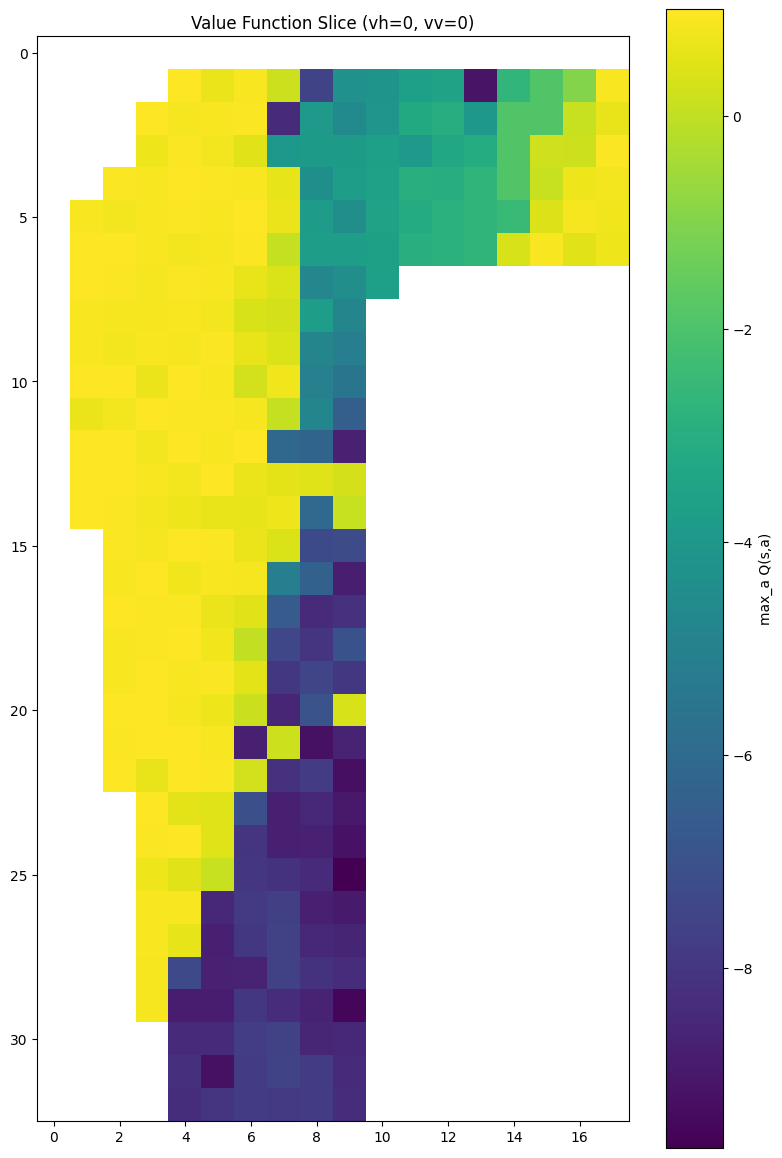

In [25]:
plot_value_heatmap(env, Q_pi, 0, 0)

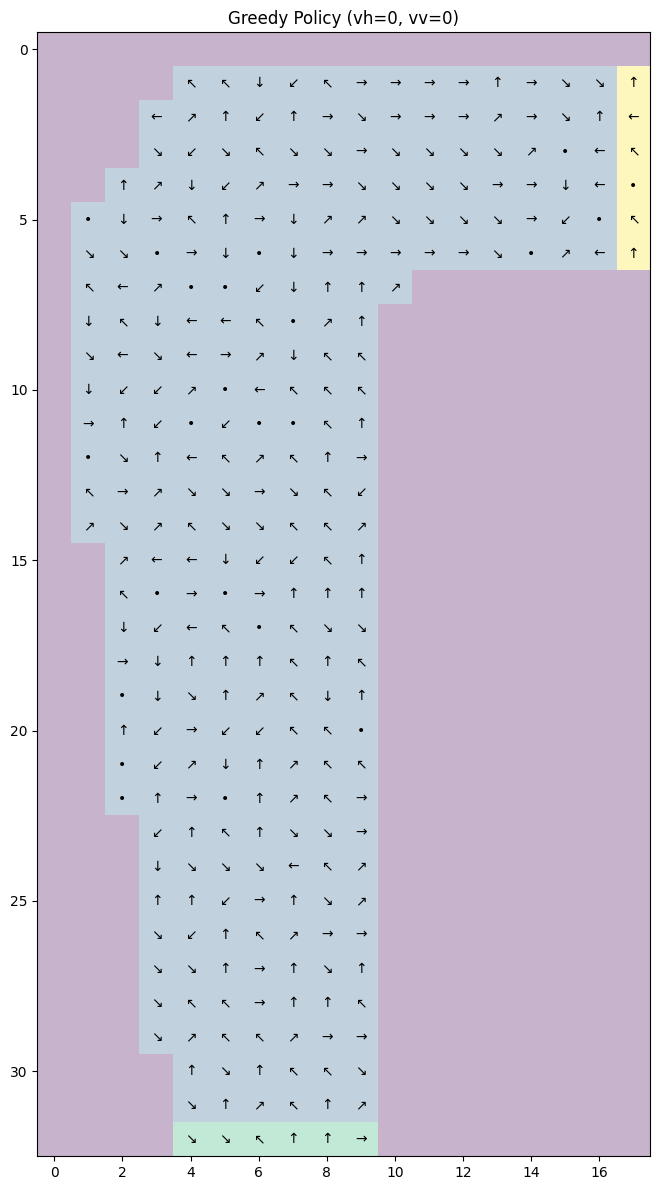

In [31]:
plot_policy(env, Q_pi, action_set, 0, 0)

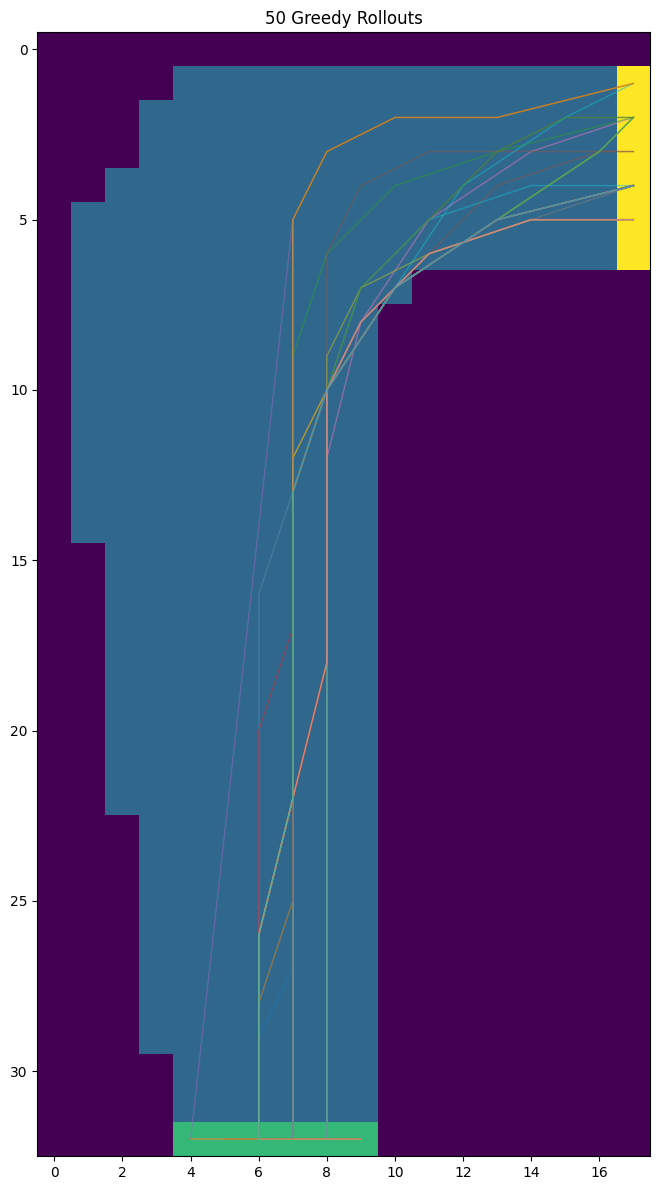

In [34]:
plot_greedy_rollouts(env, Q_pi, action_set)

In [50]:
animate_episode_with_trail(env, Q_pi, action_set)

<IPython.core.display.Javascript object>